# CH 6 — Data-Mining Bias : The Spectrum of Randomness

## Objectif pédagogique

Ce notebook transforme le concept du **spectre de l’aléatoire** en intuition quantitative et en simulation Python.

L’idée centrale est simple :

> Plus une discipline contient de **hasard** par rapport au **mérite réel**, plus la meilleure performance observée après sélection risque d’être gonflée par le **data-mining bias**.

Dans un environnement comme le trading, une stratégie peut apparaître excellente en **backtest**, non parce qu’elle possède un fort **pouvoir prédictif**, mais parce qu’elle a bénéficié d’une combinaison favorable de bruit, de chance et de sélection.


## 1. Le modèle mental : performance observée, mérite et hasard

On peut représenter la performance observée d’une règle de trading comme :

$$
P_{obs} = P_{pred} + H
$$

où :

- $P_{obs}$ est la **performance observée** dans le backtest.
- $P_{pred}$ est le **pouvoir prédictif réel**, c’est-à-dire la partie qui peut raisonnablement se répéter.
- $H$ est la composante de **hasard**, positive ou négative, qui ne garantit aucune répétition future.

> Le danger apparaît quand on teste beaucoup de règles, puis qu’on sélectionne celle qui affiche le meilleur $P_{obs}$.
>
> La sélection choisit souvent la règle qui combine un peu de mérite avec beaucoup de chance.


## 2. L’Eurêka final : le spectre de l’aléatoire

Toutes les disciplines ne vivent pas au même endroit sur le spectre **mérite vs hasard**.

| Domaine | Mérite réel | Hasard | Fiabilité de la performance observée |
|---|---:|---:|---|
| Preuve mathématique | Très élevé | Très faible | Très forte |
| Audition musicale | Élevé | Faible | Forte |
| Sport court terme | Moyen | Moyen | Moyenne |
| Trading court terme | Faible à moyen | Élevé | Faible |
| Loterie | Nul | Total | Nulle |

La phrase clé devient donc :

> **Hasard élevé = biais de minage élevé.**
>
> Le backtest ne ment pas forcément sur le classement des candidats, mais il ment souvent sur le montant de profit qu’on peut attendre.


## 3. Simulation Python : créer un univers de règles avec mérite + hasard

Nous allons simuler un univers de règles de trading candidates.

Chaque règle possède :

- un **mérite réel** $P_{pred}$ ;
- une performance observée en backtest $P_{obs}$ ;
- une performance future hors-échantillon $P_{future}$.

Le niveau de hasard sera contrôlé par un paramètre nommé `noise_level`.

Plus `noise_level` augmente, plus l’environnement ressemble au trading bruyant.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_rule_universe(
    n_rules=500,
    true_merit_mean=0.02,
    true_merit_std=0.03,
    noise_level=0.10,
    seed=42
):
    """Simule un univers de règles de trading.

    Chaque règle possède un mérite réel inconnu.
    Le backtest observe ce mérite avec du bruit.
    Le futur observe aussi ce mérite avec un nouveau bruit indépendant.
    """
    rng = np.random.default_rng(seed)

    true_merit = rng.normal(true_merit_mean, true_merit_std, n_rules)
    backtest_noise = rng.normal(0, noise_level, n_rules)
    future_noise = rng.normal(0, noise_level, n_rules)

    observed_backtest = true_merit + backtest_noise
    future_performance = true_merit + future_noise

    df = pd.DataFrame({
        "rule_id": np.arange(n_rules),
        "true_merit": true_merit,
        "backtest_performance": observed_backtest,
        "future_performance": future_performance,
        "backtest_noise": backtest_noise
    })

    df["rank_backtest"] = df["backtest_performance"].rank(ascending=False, method="first")
    df["rank_true_merit"] = df["true_merit"].rank(ascending=False, method="first")

    return df

df = simulate_rule_universe(noise_level=0.10, seed=7)
winner = df.loc[df["backtest_performance"].idxmax()]

winner


rule_id                 361.000000
true_merit                0.076126
backtest_performance      0.324761
future_performance        0.042286
backtest_noise            0.248635
rank_backtest             1.000000
rank_true_merit          10.000000
Name: 361, dtype: float64

## 4. Observer le gagnant du backtest

Le gagnant du backtest est la règle qui maximise :

$$
P_{obs} = P_{pred} + H
$$

Mais cette règle n’est pas forcément celle qui possède le meilleur $P_{pred}$.

Regardons la différence entre :

- son **profit backtesté** ;
- son **mérite réel** ;
- sa **performance future**.


In [2]:
summary = pd.DataFrame({
    "Mesure": [
        "Performance backtestée du gagnant",
        "Mérite réel du gagnant",
        "Performance future du gagnant",
        "Chance incluse dans le backtest"
    ],
    "Valeur": [
        winner["backtest_performance"],
        winner["true_merit"],
        winner["future_performance"],
        winner["backtest_noise"]
    ]
})

summary


,Mesure,Valeur
0,Performance backtestée du gagnant,0.324761
1,Mérite réel du gagnant,0.076126
2,Performance future du gagnant,0.042286
3,Chance incluse dans le backtest,0.248635


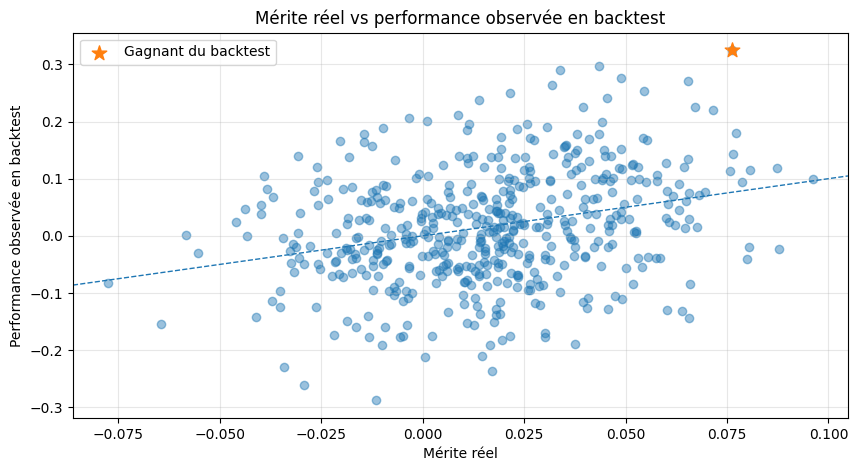

In [3]:
plt.figure(figsize=(10, 5))
plt.scatter(df["true_merit"], df["backtest_performance"], alpha=0.45)
plt.scatter(
    winner["true_merit"],
    winner["backtest_performance"],
    s=120,
    marker="*",
    label="Gagnant du backtest"
)

plt.axline((0, 0), slope=1, linestyle="--", linewidth=1)
plt.title("Mérite réel vs performance observée en backtest")
plt.xlabel("Mérite réel")
plt.ylabel("Performance observée en backtest")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Pourquoi la performance future chute presque toujours

La performance future du gagnant ne conserve pas la même chance que le backtest.

Le backtest a sélectionné une règle avec :

$$
P_{obs}^{winner} = P_{pred}^{winner} + H_{chanceux}
$$

Mais dans le futur, le hasard est renouvelé :

$$
P_{future}^{winner} = P_{pred}^{winner} + H_{nouveau}
$$

Il est donc normal que le résultat futur soit inférieur au résultat backtesté, surtout quand la règle gagnante devait une grande partie de son score à $H_{chanceux}$.


In [4]:
def run_many_experiments(
    n_experiments=1000,
    n_rules=500,
    noise_level=0.10,
    seed=123
):
    rng = np.random.default_rng(seed)
    rows = []

    for i in range(n_experiments):
        df_i = simulate_rule_universe(
            n_rules=n_rules,
            noise_level=noise_level,
            seed=int(rng.integers(0, 1_000_000_000))
        )
        w = df_i.loc[df_i["backtest_performance"].idxmax()]

        rows.append({
            "experiment": i,
            "winner_backtest": w["backtest_performance"],
            "winner_true_merit": w["true_merit"],
            "winner_future": w["future_performance"],
            "bias": w["backtest_performance"] - w["true_merit"],
            "future_deterioration": w["backtest_performance"] - w["future_performance"],
            "winner_true_rank": w["rank_true_merit"]
        })

    return pd.DataFrame(rows)

experiments = run_many_experiments(noise_level=0.10)
experiments.describe()


,experiment,winner_backtest,winner_true_merit,winner_future,bias,future_deterioration,winner_true_rank
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,0.337088,0.046316,0.049550,0.290772,0.287539,132.794000
std,288.819436,0.036416,0.029269,0.102182,0.043865,0.106911,122.626999
min,0.000000,0.251362,-0.042857,-0.282662,0.163971,-0.062137,1.000000
25%,249.750000,0.311395,0.027961,-0.018683,0.259286,0.213659,30.000000
50%,499.500000,0.332990,0.045514,0.048520,0.288132,0.293429,100.500000
75%,749.250000,0.359752,0.066652,0.121687,0.318349,0.361124,200.250000
max,999.000000,0.523916,0.136335,0.406273,0.501978,0.635790,486.000000


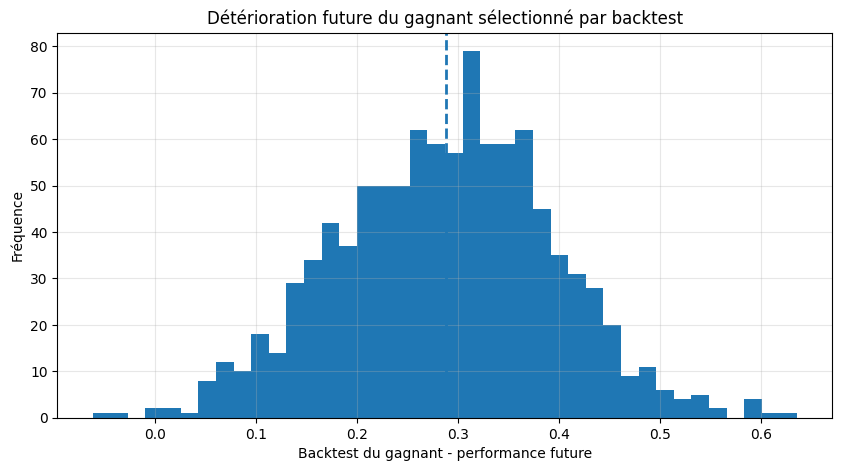

Détérioration moyenne : 0.2875
Probabilité que le futur soit inférieur au backtest : 0.997


In [5]:
plt.figure(figsize=(10, 5))
plt.hist(experiments["future_deterioration"], bins=40)
plt.axvline(experiments["future_deterioration"].mean(), linestyle="--", linewidth=2)
plt.title("Détérioration future du gagnant sélectionné par backtest")
plt.xlabel("Backtest du gagnant - performance future")
plt.ylabel("Fréquence")
plt.grid(True, alpha=0.3)
plt.show()

print("Détérioration moyenne :", round(experiments["future_deterioration"].mean(), 4))
print("Probabilité que le futur soit inférieur au backtest :", round((experiments["future_deterioration"] > 0).mean(), 3))


## 6. Le cœur du chapitre : plus de hasard = plus de biais

Nous allons maintenant comparer plusieurs mondes :

- monde peu bruité ;
- monde moyennement bruité ;
- monde très bruité.

Le **mérite réel moyen** reste identique.

La seule chose qui change est la proportion de hasard.


In [6]:
noise_levels = [0.01, 0.03, 0.06, 0.10, 0.20]
results = []

for noise in noise_levels:
    exp = run_many_experiments(
        n_experiments=1000,
        n_rules=500,
        noise_level=noise,
        seed=int(noise * 1_000_000)
    )

    results.append({
        "noise_level": noise,
        "mean_backtest_winner": exp["winner_backtest"].mean(),
        "mean_true_merit_winner": exp["winner_true_merit"].mean(),
        "mean_future_winner": exp["winner_future"].mean(),
        "mean_bias": exp["bias"].mean(),
        "mean_future_deterioration": exp["future_deterioration"].mean(),
        "prob_future_below_backtest": (exp["future_deterioration"] > 0).mean()
    })

bias_table = pd.DataFrame(results)
bias_table


,noise_level,mean_backtest_winner,mean_true_merit_winner,mean_future_winner,mean_bias,mean_future_deterioration,prob_future_below_backtest
0,0.01,0.115423,0.106064,0.105593,0.009359,0.009830,0.753
1,0.03,0.147783,0.083522,0.084253,0.064260,0.063529,0.964
2,0.06,0.223185,0.059334,0.060141,0.163851,0.163044,0.993
3,0.10,0.336964,0.046706,0.043268,0.290258,0.293696,0.994
4,0.20,0.637568,0.033691,0.032130,0.603876,0.605437,0.997


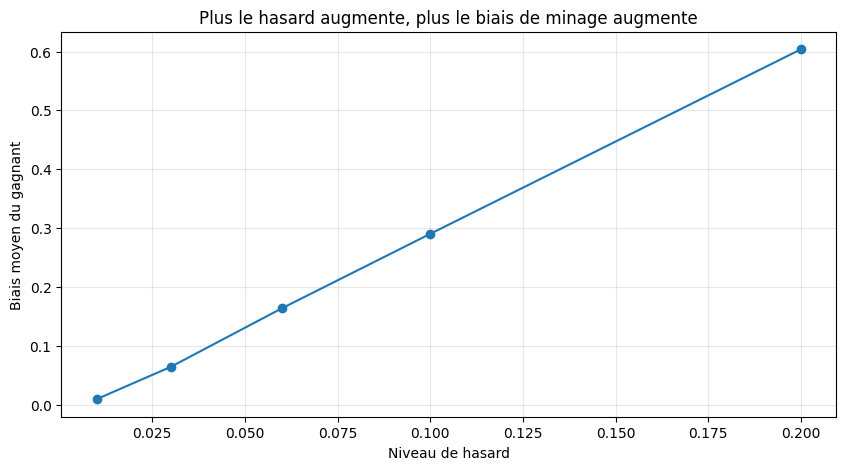

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(bias_table["noise_level"], bias_table["mean_bias"], marker="o")
plt.title("Plus le hasard augmente, plus le biais de minage augmente")
plt.xlabel("Niveau de hasard")
plt.ylabel("Biais moyen du gagnant")
plt.grid(True, alpha=0.3)
plt.show()


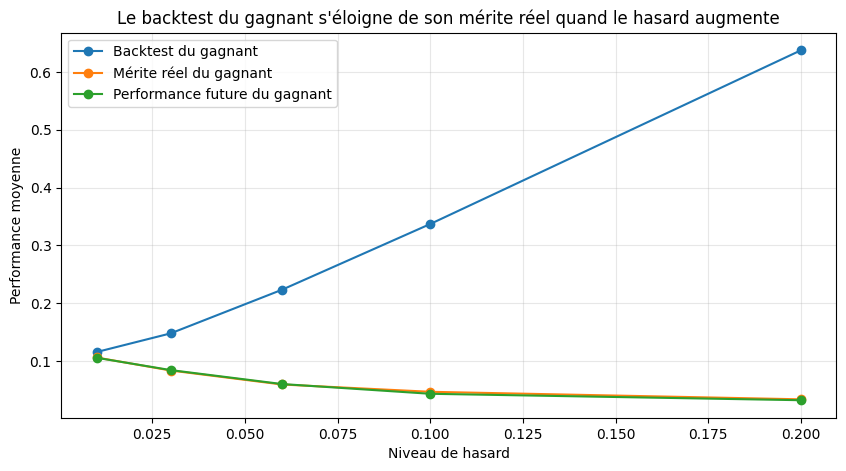

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(bias_table["noise_level"], bias_table["mean_backtest_winner"], marker="o", label="Backtest du gagnant")
plt.plot(bias_table["noise_level"], bias_table["mean_true_merit_winner"], marker="o", label="Mérite réel du gagnant")
plt.plot(bias_table["noise_level"], bias_table["mean_future_winner"], marker="o", label="Performance future du gagnant")
plt.title("Le backtest du gagnant s'éloigne de son mérite réel quand le hasard augmente")
plt.xlabel("Niveau de hasard")
plt.ylabel("Performance moyenne")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Interprétation trading

Dans un univers de trading très bruité, la meilleure règle du backtest est souvent un mélange de deux choses :

$$
\text{Gagnant du backtest} = \text{un peu de mérite} + \text{beaucoup de chance}
$$

Cela ne signifie pas que le minage de données est inutile.

Cela signifie qu’il faut distinguer deux promesses :

| Promesse | Ce que le minage peut faire | Risque |
|---|---|---|
| Sélection | Trouver un bon candidat relatif | Utile, mais imparfait |
| Estimation | Dire combien il rapportera vraiment | Très dangereux |

> **L’erreur du trader n’est pas de chercher la meilleure règle.**
>
> **L’erreur est de croire que le profit backtesté du gagnant est une estimation fiable de son profit futur.**


## 8. Exemple concret : optimisation de paramètres

Imagine une stratégie simple avec un paramètre de lookback.

Tu testes :

$$
L \in \{5, 6, 7, \dots, 200\}
$$

Même si aucun paramètre ne possède un edge réel énorme, l’un d’eux affichera probablement une courbe magnifique par hasard.

Plus tu ajoutes de paramètres, plus tu agrandis l’univers de recherche :

$$
N_{combinaisons} = N_1 \times N_2 \times N_3 \times \dots
$$

Et plus tu augmentes la probabilité de trouver un gagnant accidentel.


In [9]:
def simulate_parameter_search(n_candidates_list, noise_level=0.10, seed=99):
    rng = np.random.default_rng(seed)
    rows = []

    for n_candidates in n_candidates_list:
        exp = run_many_experiments(
            n_experiments=1000,
            n_rules=n_candidates,
            noise_level=noise_level,
            seed=int(rng.integers(0, 1_000_000_000))
        )

        rows.append({
            "n_candidates": n_candidates,
            "mean_backtest_winner": exp["winner_backtest"].mean(),
            "mean_true_merit_winner": exp["winner_true_merit"].mean(),
            "mean_bias": exp["bias"].mean()
        })

    return pd.DataFrame(rows)

search_size_table = simulate_parameter_search(
    n_candidates_list=[10, 25, 50, 100, 250, 500, 1000, 2000],
    noise_level=0.10
)

search_size_table


,n_candidates,mean_backtest_winner,mean_true_merit_winner,mean_bias
0,10,0.181787,0.034219,0.147568
1,25,0.226010,0.036528,0.189483
2,50,0.255867,0.039907,0.215960
3,100,0.282013,0.040659,0.241354
4,250,0.315321,0.043943,0.271379
5,500,0.335741,0.044956,0.290785
6,1000,0.357797,0.046983,0.310815
7,2000,0.380141,0.050430,0.329711


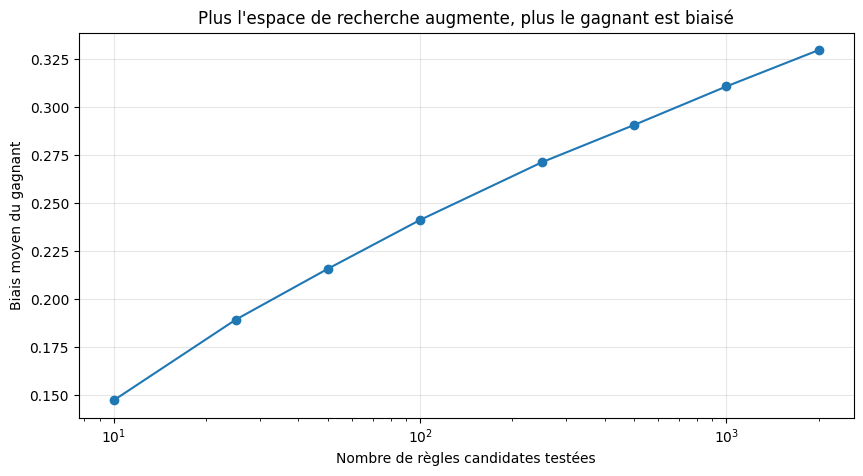

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(search_size_table["n_candidates"], search_size_table["mean_bias"], marker="o")
plt.xscale("log")
plt.title("Plus l'espace de recherche augmente, plus le gagnant est biaisé")
plt.xlabel("Nombre de règles candidates testées")
plt.ylabel("Biais moyen du gagnant")
plt.grid(True, alpha=0.3)
plt.show()


## 9. Checklist EBTA : comment ne pas se faire piéger

Pour un trader systématique, ce chapitre implique une discipline stricte :

| Question | Interprétation |
|---|---|
| Combien de règles ou variantes ai-je testées ? | Plus le nombre est grand, plus le biais potentiel augmente. |
| Le marché testé est-il très bruité ? | Plus le bruit est élevé, plus le backtest du gagnant est suspect. |
| Ai-je une validation hors-échantillon ? | Sans validation, le profit backtesté peut être du métal des fous. |
| Ai-je estimé l’incertitude ? | Un profit sans intervalle de confiance est une illusion de précision. |
| Ai-je réduit l’espace de recherche avant de tester ? | Moins de liberté = moins de sur-ajustement. |

> Le bon réflexe n’est pas : “Cette stratégie a fait $80\%$, donc elle est excellente.”
>
> Le bon réflexe est : “Combien de cette performance vient du mérite réel, et combien vient du hasard sélectionné ?”


## 10. Résumé final

À retenir absolument :

- La performance observée mélange **pouvoir prédictif** et **hasard**.
- Le **data-mining bias** apparaît quand on sélectionne le meilleur résultat parmi beaucoup de candidats.
- Plus l’environnement est bruité, plus la meilleure performance observée est gonflée.
- Le trading, surtout court terme, se situe fortement du côté **hasard** du spectre.
- Le minage peut aider à **choisir un candidat**, mais il surestime souvent **combien ce candidat rapportera**.
- La performance future sera souvent inférieure au backtest, non parce que le marché a trahi la stratégie, mais parce que la chance passée ne se répète pas.

> **L’Eurêka final : dans un domaine dominé par le hasard, le gagnant du passé est souvent le champion de la chance, pas le champion du mérite.**


## Annexe — Source originale fournie

Le texte ci-dessous est conservé comme annexe pour garder la trace du matériau de départ.


### **CH 6 : DA11\·M1MNG BIAS: AN EFFECT WITH lWO CAUSES - THE SPECTRUM OF RANDOMNESS**

Voici l’analyse technique de la section portant sur le spectre de l’aléatoire, un cadre conceptuel permettant de comprendre pourquoi certaines disciplines, comme le trading, sont plus vulnérables au biais de minage de données que d'autres.

#### **Idées clés :**
*   **Les deux extrêmes :** La performance observée se situe sur un spectre allant de la domination totale du mérite (preuve mathématique) à la domination totale du hasard (loterie).
*   **Lien direct avec le biais :** Plus la part de hasard dans une discipline est grande par rapport au mérite, plus l'ampleur du biais de minage de données est élevée.
*   **Position de l'Analyse Technique (AT) :** Les règles d'AT se situent très près de l'extrémité « hasard » du spectre en raison de la complexité et du bruit des marchés financiers.
*   **Les deux promesses du minage :** Le minage de données réussit à identifier la *meilleure* règle, mais échoue systématiquement à estimer *combien* elle rapportera réellement.

#### **Référence :**
*The Spectrum of Randomness / The Effectiveness of MCP under Differing Conditions of Randomness*, pages 279 à 281.

#### **Citation Directe :**
« The larger the contribution of randomness (luck) relative to merit in observed performance, the larger will be the magnitude of the data-mining bias. » (Page 280).

---

#### **Vision Macro :**
L'enjeu est de comprendre la "qualité" de l'information extraite des données. David Aronson explique que le minage de données n'est pas une méthode défectueuse en soi, mais que ses résultats sont pollués par l'environnement dans lequel elle est appliquée. Dans un domaine comme la musique classique, le meilleur est choisi pour son talent ; en trading, le "meilleur" d'un backtest est souvent choisi parce qu'il a été le plus chanceux face au bruit. Le trader doit donc accepter que sa "meilleure" stratégie est le fruit d'un processus de sélection efficace, mais dont les profits passés sont une promesse non tenue.

---

#### **Vision Micro :**
Le mécanisme du spectre de l'aléatoire et ses conséquences techniques se décomposent ainsi :

1.  **L'échelle de mérite vs hasard (Figure 6.12) :** 
    *   **Domination du mérite :** disciplines où la chance joue un rôle mineur (ex: résoudre un théorème, performance d'un musicien de concert). Ici, la performance observée est un indicateur fiable du mérite réel.
    *   **Domination du hasard :** disciplines où la chance est le facteur principal (ex: loterie, singes écrivains, trading de court terme).
2.  **L'impact sur le minage (MCP) :** 
    *   **Promesse 1 (Sélection) :** White a prouvé mathématiquement que même avec beaucoup de hasard, la règle qui affiche le meilleur profit passé est *statistiquement* celle qui a le plus de chances d'être la meilleure dans le futur. Le minage remplit donc son rôle de boussole.
    *   **Promesse 2 (Estimation) :** En revanche, le profit affiché par cette règle est un "estimateur biaisé". Dans l'AT, la boîte "Hasard" de l'équation est si large qu'elle occulte presque totalement la boîte "Pouvoir Prédictif" (Figure 6.13), gonflant artificiellement le résultat.
3.  **La conséquence inévitable :** Puisque l'AT se situe dans la zone de forte dominance du hasard, le biais de minage y est structurellement massif.

---

#### **Résumé Simplifié :**
Le minage de données est comme un concours de tir. Si vous tirez par temps clair (peu de hasard), le gagnant est le meilleur tireur. Si vous tirez dans un brouillard total (marchés financiers), le gagnant est juste celui qui a eu de la chance. David Aronson nous dit : l'ordinateur est très doué pour trouver le "moins mauvais" tireur dans le brouillard, mais ne croyez pas qu'il tirera aussi bien une fois que vous l'engagerez, car son score était un coup de chance.

#### **Exemples du livre pour mieux comprendre :**
*   **Le premier violon de l'orchestre :** Pour recruter un musicien, on lui demande de jouer à vue. La chance (un pneu crevé sur la route, une dispute matinale) a un impact si faible que le meilleur musicien gagnera presque toujours, et sa performance au test sera identique à sa performance future en concert.
*   **Le singe écrivain :** Si vous faites danser 10 000 singes sur des claviers, l'un d'eux finira par écrire une phrase cohérente. C'est l'extrémité "Hasard" du spectre : le succès passé du singe a une valeur prédictive de zéro pour le concert du lendemain.

---

#### **Actions Concrètes :**
*   **Ajuster le niveau de scepticisme :** Plus votre stratégie semble "miraculeuse" dans un environnement bruyant (comme le trading intraday), plus vous devez considérer que vous êtes face à du « métal des fous » (*Fool's Gold*).
*   **Valider la sélection, pas le montant :** Utilisez le minage pour choisir votre stratégie, mais ne basez jamais vos plans de vie sur le rendement annuel qu'elle affiche en backtest.
*   **Réduire l'espace de recherche :** Bien que White dise que le minage trouve le meilleur, Aronson rappelle que plus l'univers de recherche est grand, plus le "gagnant par accident" sera éloigné de la vérité.

---

#### **À retenir absolument :**
*   **Hasard élevé = Biais élevé**.
*   Le trading se situe du côté **Hasard** du spectre.
*   Le minage de données trouve le **meilleur candidat**, mais **ment sur son profit**.
*   Dans l'AT, le hasard **domine** le pouvoir prédictif.
*   La performance réelle sera **presque toujours pire** que le backtest.

J'ai terminé l'analyse du spectre de l'aléatoire selon le protocole EBTA.
